In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

import statsmodels.api as sm
from statsmodels.tsa.filters.hp_filter import hpfilter
from scipy.stats import norm
from scipy import stats


## Ejercicio 1

In [23]:
z = np.arange(-10,10,0.1) # Me armo la columna desde -10 a 10

normal_n1_9 = norm.pdf(z, loc=-1, scale=3) # sqrt(9) = 3 aca ponemos el desvest no la Var
normal_n1_4 = norm.pdf(z, loc=-1, scale=2)

mixtura = 0.4 * normal_n1_9 + normal_n1_4 * 0.6

pdf = pd.DataFrame({
"z": z ,
"pdf_n1_9": normal_n1_9,
"pdf_n1_4": normal_n1_4,
"pdf_mix": mixtura
})

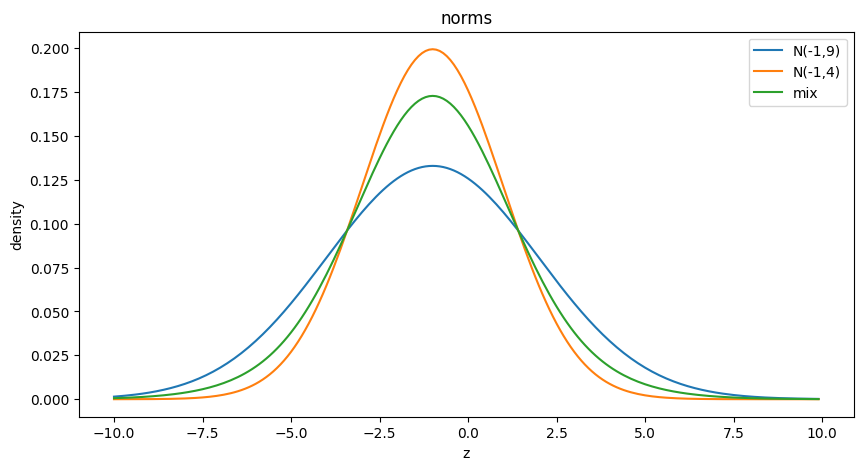

In [25]:
plt.figure(figsize=(10,5))

plt.plot(pdf['z'],pdf['pdf_n1_9'],label='N(-1,9)')
plt.plot(pdf['z'],pdf['pdf_n1_4'],label='N(-1,4)')
plt.plot(pdf['z'],pdf['pdf_mix'],label='mix')

plt.title('norms')
plt.xlabel('z')
plt.ylabel('density')
plt.legend()
plt.show()

Viendo solo el grafico y a sabiendas de su media se que es simetrica. 

In [26]:

w1=0.4
w2=0.6
mu1 = -1
mu2= -1
var1 = 9
var2 = 4
sigma1 = np.sqrt(9)
sigma2 = np.sqrt(4)

# Media de la mixtura
media_mix = -1

# Varianza de la mixtura
var_mix = (
    w1 * (var1 + (mu1 - media_mix)**2)
    + w2 * (var2 + (mu2 - media_mix)**2)
)

# Momentos centrales 3 y 4 de la mixtura
mu3_mix = (
    w1 * ((mu1 - media_mix)**3 + 3 * (mu1 - media_mix) * var1)
    + w2 * ((mu2 - media_mix)**3 + 3 * (mu2 - media_mix) * var2)
)

mu4_mix = (
    w1 * ((mu1 - media_mix)**4 + 6 * (mu1 - media_mix)**2 * var1 + 3 * var1**2)
    + w2 * ((mu2 - media_mix)**4 + 6 * (mu2 - media_mix)**2 * var2 + 3 * var2**2)
)

asimetria = mu3_mix / (var_mix ** 1.5)
curtosis = mu4_mix / (var_mix ** 2)

print(f' Para la mixtura, la media es {media_mix} y su varianza es {var_mix} \n la asimetria es {asimetria}\n su K {curtosis}')

 Para la mixtura, la media es -1 y su varianza es 6.0 
 la asimetria es 0.0
 su K 3.5


Por lo que vemos el resultado de su curtosis. es leptocurtica, es decir que  sus colas son mas PESADAS porque aparecen mas frecuentemente los valores extremos de lo que deberia

In [27]:
varm = np.sqrt(6)
normal_n1_6 = norm.pdf(z, loc=-1, scale=varm) 

pdf['pdf_n1_6'] = normal_n1_6

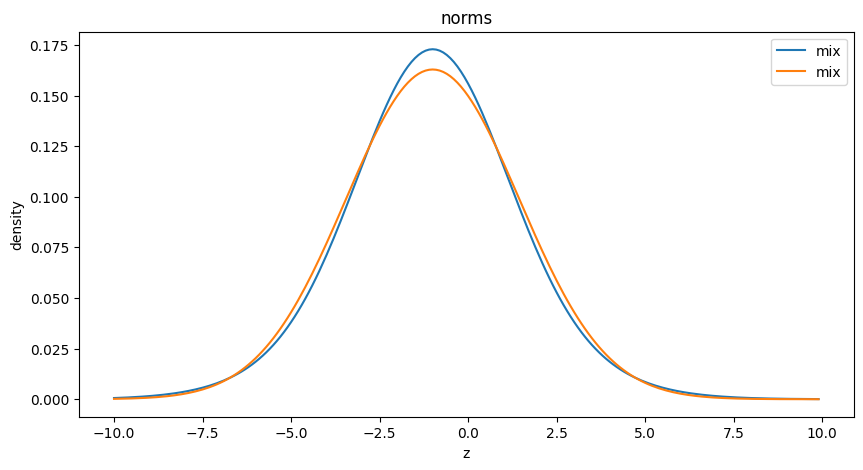

In [28]:
plt.figure(figsize=(10,5))

plt.plot(pdf['z'],pdf['pdf_mix'],label='mix')
plt.plot(pdf['z'],pdf['pdf_n1_6'],label='mix')

plt.title('norms')
plt.xlabel('z')
plt.ylabel('density')
plt.legend()
plt.show()

no son iguales 

In [35]:
from scipy import stats

np.random.seed(123)

n = 2000

df_sim = pd.DataFrame()

df_sim["N(-1,9)"] = np.random.normal(loc=mu1, scale=np.sqrt(var1), size=n)
df_sim["N(-1,4)"] = np.random.normal(loc=mu2, scale=np.sqrt(var2), size=n)
df_sim["U"] = np.random.uniform(0, 1, size=n)
df_sim["N(-1,6)"] = np.random.normal(loc=-1, scale=np.sqrt(varm), size=n)

df_sim["compound_mix"] = np.where(
    df_sim["U"] < w1,
    df_sim["N(-1,9)"],
    df_sim["N(-1,4)"]

)

df_sim.head()

,"N(-1,9)","N(-1,4)",U,"N(-1,6)",compound_mix
0,-4.256892,-4.548447,0.823348,-0.343226,-4.548447
1,1.992036,-3.402755,0.359432,-0.358008,1.992036
2,-0.151065,1.192514,0.177570,-2.551281,-0.151065
3,-5.518884,0.722074,0.162485,-2.244427,-5.518884
4,-2.735801,-4.040734,0.574017,0.303741,-4.040734


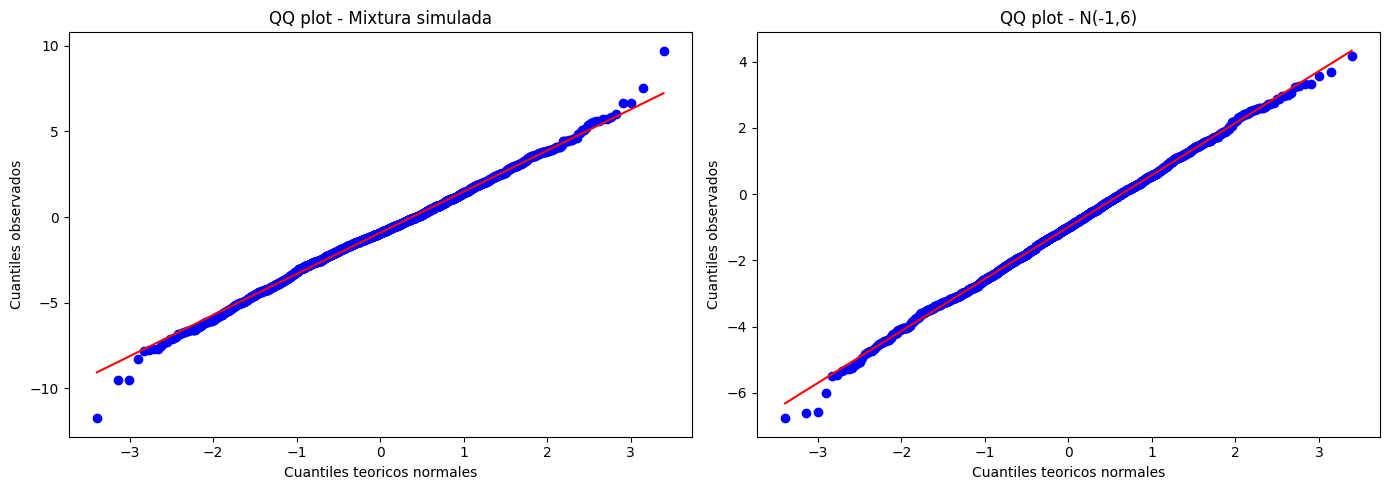

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

stats.probplot(df_sim["compound_mix"], dist="norm", plot=axes[0])
axes[0].set_title("QQ plot - Mixtura simulada")
axes[0].set_xlabel("Cuantiles teoricos normales")
axes[0].set_ylabel("Cuantiles observados")

stats.probplot(df_sim["N(-1,6)"], dist="norm", plot=axes[1])
axes[1].set_title("QQ plot - N(-1,6)")
axes[1].set_xlabel("Cuantiles teoricos normales")
axes[1].set_ylabel("Cuantiles observados")

plt.tight_layout()
plt.show()

## Ejercicio 2

In [37]:
z = np.arange(-10,10,0.1) # Me armo la columna desde -10 a 10

ceroceronueve = np.sqrt(0.09)
normal_12_009 = norm.pdf(z, loc=-1, scale=ceroceronueve)
ceroochouno = np.sqrt(0.81)
normal_m08_081 = norm.pdf(z, loc=-0.8, scale=ceroochouno)

mixtura2 = 0.35 * normal_12_009 + normal_m08_081 * 0.65

pdf = pd.DataFrame({
"z": z ,
"pdf_12_009": normal_12_009,
"pdf_n08_081": normal_m08_081,
"mix2": mixtura2
})

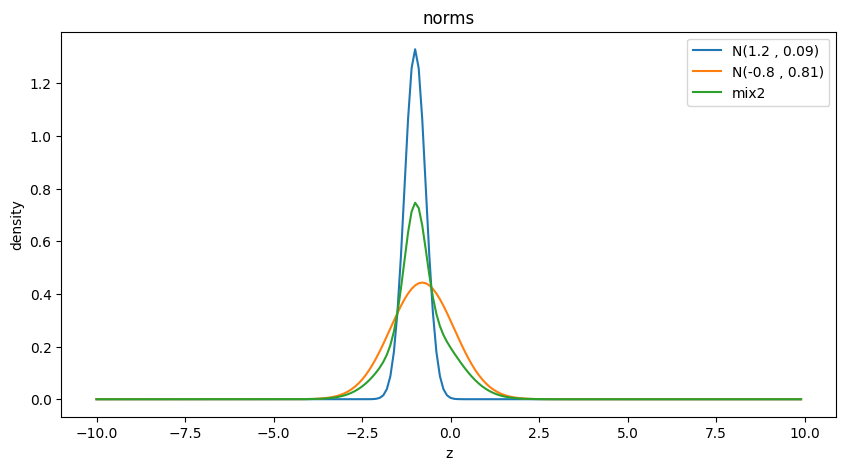

In [38]:
plt.figure(figsize=(10,5))

plt.plot(pdf['z'],pdf['pdf_12_009'],label='N(1.2 , 0.09)')
plt.plot(pdf['z'],pdf['pdf_n08_081'],label='N(-0.8 , 0.81)')
plt.plot(pdf['z'],pdf['mix2'],label='mix2')

plt.title('norms')
plt.xlabel('z')
plt.ylabel('density')
plt.legend()
plt.show()

Tiene la cola izq levemente mas pegagada que la derecha. Platicurtica

In [39]:

w1=0.35
w2=0.65
mu1 = 1.2
mu2= -0.8
var1 = 0.09
var2 = 0.81
sigma1 = np.sqrt(0.09)
sigma2 = np.sqrt(0.81)

# Media de la mixtura
media_mix = w1 * mu1 + mu2 * w2

# Varianza de la mixtura
var_mix = (
    w1 * (var1 + (mu1 - media_mix)**2)
    + w2 * (var2 + (mu2 - media_mix)**2)
)

# Momentos centrales 3 y 4 de la mixtura
mu3_mix = (
    w1 * ((mu1 - media_mix)**3 + 3 * (mu1 - media_mix) * var1)
    + w2 * ((mu2 - media_mix)**3 + 3 * (mu2 - media_mix) * var2)
)

mu4_mix = (
    w1 * ((mu1 - media_mix)**4 + 6 * (mu1 - media_mix)**2 * var1 + 3 * var1**2)
    + w2 * ((mu2 - media_mix)**4 + 6 * (mu2 - media_mix)**2 * var2 + 3 * var2**2)
)

asimetria = mu3_mix / (var_mix ** 1.5)
curtosis = mu4_mix / (var_mix ** 2)

print(f' Para la mixtura, la media es {media_mix} y su varianza es {var_mix} \n la asimetria es {asimetria}\n su K {curtosis}')

 Para la mixtura, la media es -0.10000000000000003 y su varianza es 1.468 
 la asimetria es -0.24558031174186698
 su K 2.0004046358648444


Asimetrica negativa y platicurtica

In [40]:
varm2 = np.sqrt(1.468)
normal_m01_1468 = norm.pdf(z, loc=-0.10000000000000003, scale=varm2)


In [41]:
pdf['pdf_n01_1468'] = normal_m01_1468

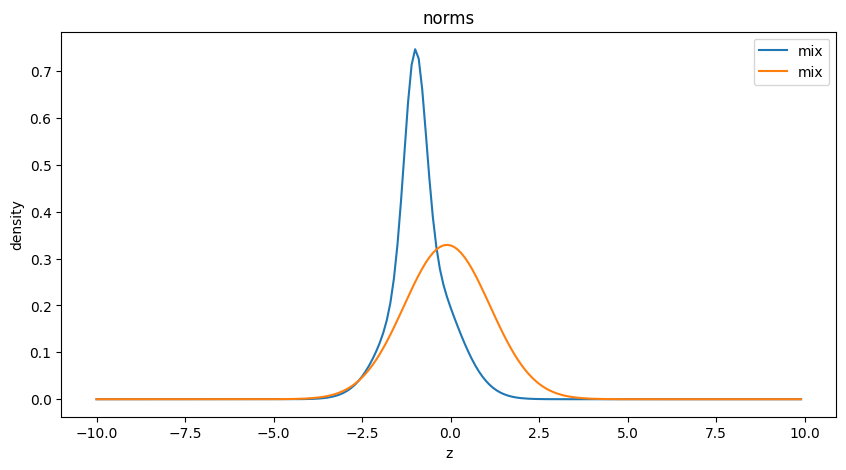

In [42]:
plt.figure(figsize=(10,5))

plt.plot(pdf['z'],pdf['mix2'],label='mix')
plt.plot(pdf['z'],pdf['pdf_n01_1468'],label='mix')

plt.title('norms')
plt.xlabel('z')
plt.ylabel('density')
plt.legend()

In [44]:
np.random.seed(123)

n = 2000

df_sim2 = pd.DataFrame()

df_sim2["N(1.2,0.09)"] = np.random.normal(loc=mu1, scale=np.sqrt(var1), size=n)
df_sim2["N(-0.8,0.81)"] = np.random.normal(loc=mu2, scale=np.sqrt(var2), size=n)
df_sim2["U"] = np.random.uniform(0, 1, size=n)
df_sim2["N(0.10000000000000003,1.468)"] = np.random.normal(loc=-0.10000000000000003, scale=np.sqrt(varm2), size=n)

df_sim2["compound_mix2"] = np.where(
    df_sim2["U"] < w1,
    df_sim2["N(1.2,0.09)"],
    df_sim2["N(-0.8,0.81)"]

)

df_sim2.head()

,"N(1.2,0.09)","N(-0.8,0.81)",U,"N(0.10000000000000003,1.468)",compound_mix2
0,0.874311,-2.396801,0.823348,0.361912,-2.396801
1,1.499204,-1.881240,0.359432,0.351516,-1.881240
2,1.284894,0.186631,0.177570,-1.191024,1.284894
3,0.748112,-0.025067,0.162485,-0.975212,0.748112
4,1.026420,-2.168330,0.574017,0.816927,-2.168330


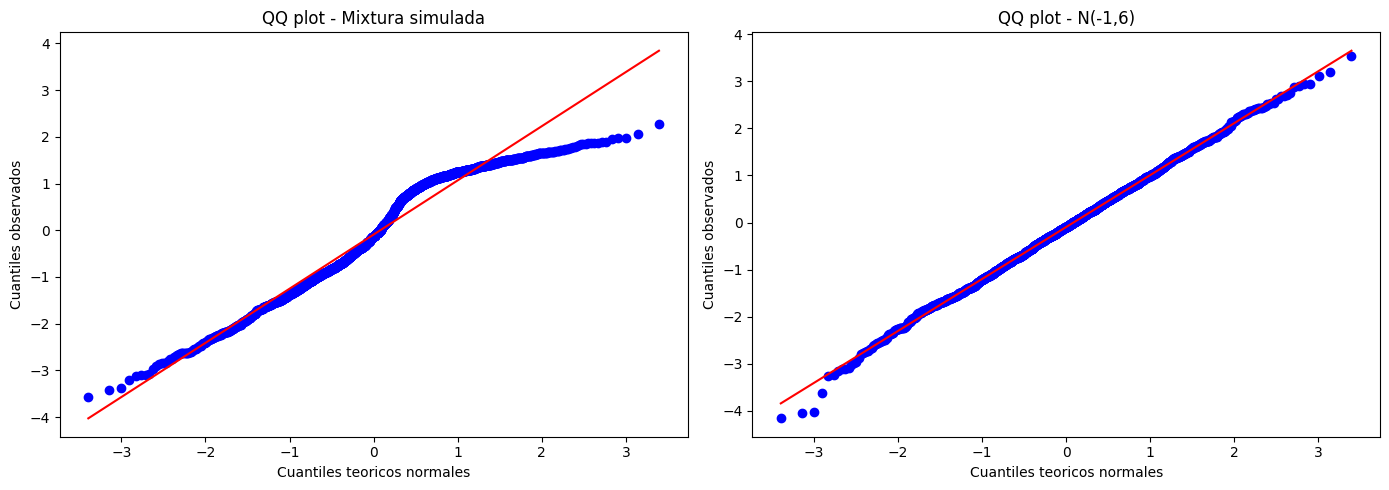

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

stats.probplot(df_sim2["compound_mix2"], dist="norm", plot=axes[0])
axes[0].set_title("QQ plot - Mixtura simulada")
axes[0].set_xlabel("Cuantiles teoricos normales")
axes[0].set_ylabel("Cuantiles observados")

stats.probplot(df_sim2["N(0.10000000000000003,1.468)"], dist="norm", plot=axes[1])
axes[1].set_title("QQ plot - N(-1,6)")
axes[1].set_xlabel("Cuantiles teoricos normales")
axes[1].set_ylabel("Cuantiles observados")

plt.tight_layout()
plt.show()

NO SON NADA QUE VER


## Ejercicio 3

In [3]:
import os, platform

print(platform.system())
print(os.getcwd())

Darwin
/Users/bautistagianfrancisco/Library/Mobile Documents/com~apple~CloudDocs/MIA 2026/2 Trim/Modelado Estocastico/Practicas_Resueltas


In [4]:
os.chdir("/Users/bautistagianfrancisco/Library/Mobile Documents/com~apple~CloudDocs/MIA 2026/2 Trim/Modelado Estocastico")

In [5]:
import os

os.path.exists("Excels/MIA103_Clase_2.xlsx")

True

In [6]:
usa = pd.read_excel(
    "Excels/MIA103_Clase_2.xlsx",
    sheet_name="PBI Real USA",
    usecols="B:C",
    skiprows=10,
    nrows=96
)

usa.head()

,Año,GDPCA
0,1929,1191.124
1,1930,1089.785
2,1931,1019.977
3,1932,888.414
4,1933,877.431


In [9]:
usa.columns = ["anio", "pbi_real"]

usa.head()

,anio,pbi_real
0,1929,1191.124
1,1930,1089.785
2,1931,1019.977
3,1932,888.414
4,1933,877.431


In [11]:
usa["log_pbi"] = np.log(usa["pbi_real"])

usa.head()

,anio,pbi_real,log_pbi
0,1929,1191.124,7.082653
1,1930,1089.785,6.993736
2,1931,1019.977,6.927535
3,1932,888.414,6.789438
4,1933,877.431,6.776998


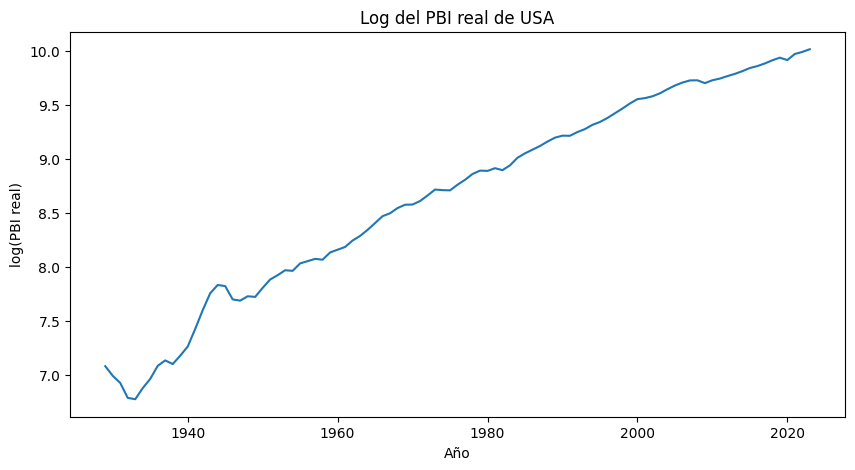

In [12]:
plt.figure(figsize=(10, 5))

plt.plot(usa["anio"], usa["log_pbi"])

plt.title("Log del PBI real de USA")
plt.xlabel("Año")
plt.ylabel("log(PBI real)")
plt.show()

In [13]:
usa["tendencia_mm11"] = usa["log_pbi"].rolling(window=11, center=True).mean()

usa["ciclo_mm11"] = usa["log_pbi"] - usa["tendencia_mm11"]

usa.head(15)

,anio,pbi_real,log_pbi,tendencia_mm11,ciclo_mm11
0,1929,1191.124,7.082653,NaN,NaN
1,1930,1089.785,6.993736,NaN,NaN
2,1931,1019.977,6.927535,NaN,NaN
3,1932,888.414,6.789438,NaN,NaN
4,1933,877.431,6.776998,NaN,NaN
5,1934,972.263,6.879626,6.992644,-0.113018
6,1935,1058.836,6.964925,7.009138,-0.044213
7,1936,1195.251,7.086111,7.048541,0.037570
8,1937,1256.503,7.136088,7.109690,0.026397
9,1938,1214.869,7.102392,7.197685,-0.095293


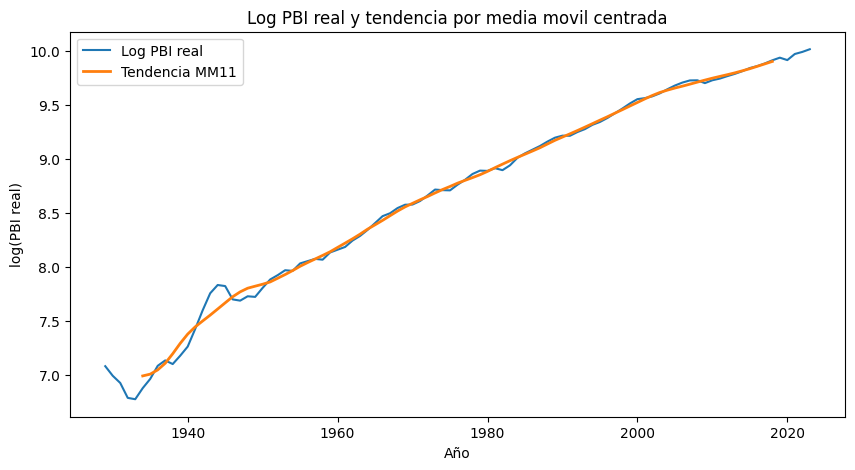

In [14]:
plt.figure(figsize=(10, 5))

plt.plot(usa["anio"], usa["log_pbi"], label="Log PBI real")
plt.plot(usa["anio"], usa["tendencia_mm11"], label="Tendencia MM11", linewidth=2)

plt.title("Log PBI real y tendencia por media movil centrada")
plt.xlabel("Año")
plt.ylabel("log(PBI real)")
plt.legend()
plt.show()

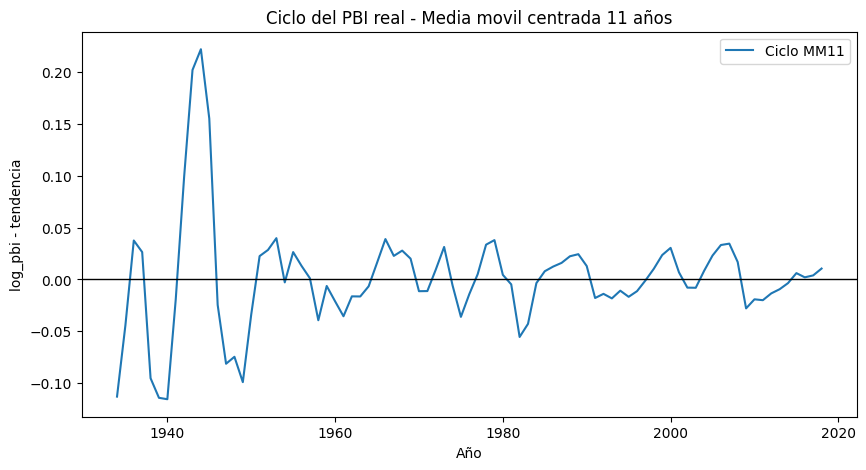

In [15]:
plt.figure(figsize=(10, 5))

plt.plot(usa["anio"], usa["ciclo_mm11"], label="Ciclo MM11")
plt.axhline(0, color="black", linewidth=1)

plt.title("Ciclo del PBI real - Media movil centrada 11 años")
plt.xlabel("Año")
plt.ylabel("log_pbi - tendencia")
plt.legend()
plt.show()

In [ ]:
"""
La media movil centrada de 11 años aproxima la tendencia de largo plazo del log
del PBI real. Al restar la tendencia a la serie original obtenemos el ciclo.

Cuando el ciclo es positivo, el PBI real se encuentra por encima de su tendencia.
Cuando el ciclo es negativo, se encuentra por debajo de su tendencia.

Los primeros y ultimos años quedan con valores NaN porque una media movil
centrada necesita observaciones antes y despues del año analizado.
"""

In [16]:
from statsmodels.tsa.filters.hp_filter import hpfilter

usa["ciclo_hp"], usa["tendencia_hp"] = hpfilter(usa["log_pbi"], lamb=100)

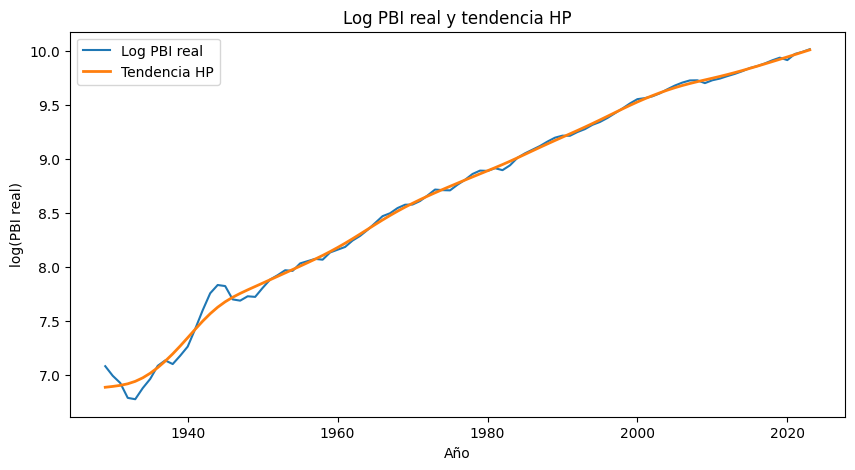

In [17]:
plt.figure(figsize=(10, 5))

plt.plot(usa["anio"], usa["log_pbi"], label="Log PBI real")
plt.plot(usa["anio"], usa["tendencia_hp"], label="Tendencia HP", linewidth=2)

plt.title("Log PBI real y tendencia HP")
plt.xlabel("Año")
plt.ylabel("log(PBI real)")
plt.legend()
plt.show()

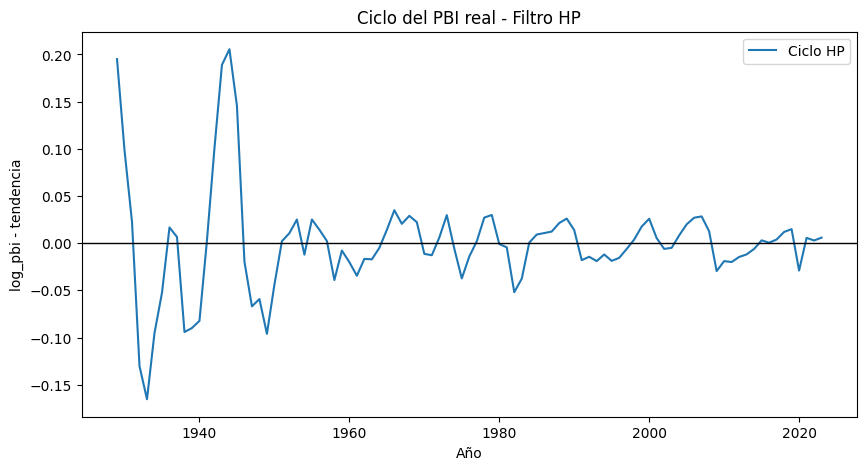

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(usa["anio"], usa["ciclo_hp"], label="Ciclo HP")
plt.axhline(0, color="black", linewidth=1)

plt.title("Ciclo del PBI real - Filtro HP")
plt.xlabel("Año")
plt.ylabel("log_pbi - tendencia")
plt.legend()
plt.show()

In [ ]:
"""
El filtro HP separa el log del PBI real en una tendencia suave y un componente
ciclico. A diferencia de la media movil centrada, el filtro HP permite obtener
valores de tendencia y ciclo también en los extremos de la muestra.

Con lambda=100, usual para datos anuales, la tendencia captura el crecimiento de
largo plazo y el ciclo mide los desvios transitorios respecto de esa tendencia.
"""